In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

In [2]:

print("Downloading AAPL data...")

df = yf.download("AAPL", period="5y", auto_adjust=True)

# Keep only the closing price column
df = df[["Close"]].copy()
df.dropna(inplace=True)

print(f"Downloaded {len(df)} trading days of data.")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Downloaded 1255 trading days of data.
Price            Close
Ticker            AAPL
Date                  
2021-04-08  126.970062
2021-04-09  129.541397
2021-04-12  127.827187
2021-04-13  130.934219
2021-04-14  128.596634


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df["Close"].values.reshape(-1, 1))

In [4]:
WINDOW_SIZE = 60  # number of past days to look at

X = []
y = []

for i in range(WINDOW_SIZE, len(scaled_data)):
    X.append(scaled_data[i - WINDOW_SIZE:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")






X shape: (1195, 60, 1)
y shape: (1195,)


In [5]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 956
Testing  samples : 239


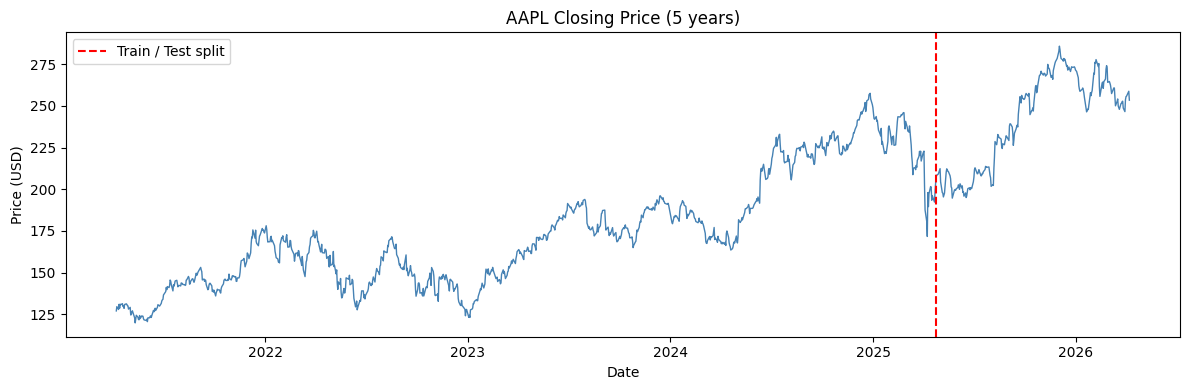


Chart saved to outputs/aapl_price_chart.png

Preprocessing complete! Variables ready: X_train, X_test, y_train, y_test, scaler


In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["Close"], color="steelblue", linewidth=1)
plt.axvline(df.index[split + WINDOW_SIZE], color="red",
            linestyle="--", label="Train / Test split")
plt.title("AAPL Closing Price (5 years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/aapl_price_chart.png", dpi=150)
plt.show()
print("\nChart saved to outputs/aapl_price_chart.png")

print("\nPreprocessing complete! Variables ready: X_train, X_test, y_train, y_test, scaler")

C:\Users\manda\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 120ms/step - loss: 0.0200 - val_loss: 0.0080
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0037 - val_loss: 0.0090
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0031 - val_loss: 0.0053
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0028 - val_loss: 0.0050
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0024 - val_loss: 0.0056
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0023 - val_loss: 0.0044
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0024 - val_loss: 0.0043
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0022 - val_loss: 0.0045
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0019 - val_loss: 0.0039
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0021 - val_loss: 0.0042
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0019 - val_loss: 0.0038
Epoch 12/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0

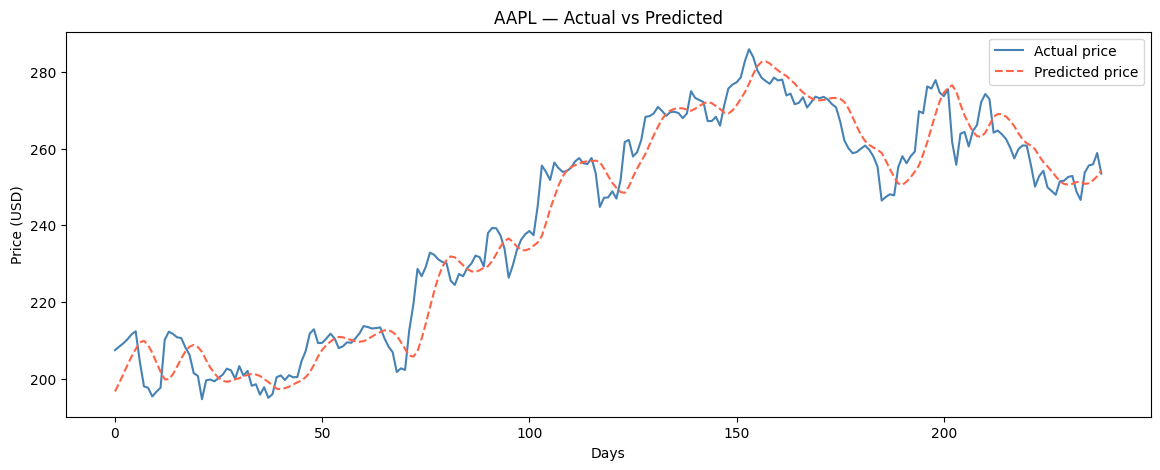

In [7]:
# ================================================
#  LSTM Stock Price Prediction — AAPL
#  Run preprocess.py first before this file!
# ================================================

# ── Part 1: Imports ──────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ── Part 2: Build Model ──────────────────────────
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(60, 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=1))

# ── Part 3: Compile ──────────────────────────────
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# ── Part 4: Train ────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ── Part 5: Predict ──────────────────────────────
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# ── Part 6: Plot ─────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, color='steelblue', label='Actual price')
plt.plot(predictions, color='tomato', linestyle='--', label='Predicted price')
plt.title('AAPL — Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()